In [2]:
import os,sys
import numpy as np
import configparser
import matplotlib.pyplot as plt
import matplotlib
import argparse
from psana import DataSource
from numba import jit, njit
import scipy.ndimage.measurements as smt
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *
from UEDePixTools import *
from tqdm import tqdm
from PIL import Image
from matplotlib.colors import LogNorm
# %matplotlib widget

In [32]:
# exp and run infor and load raw data using LCLS DataSource
exp = 'ued1015999'  # experiment
run = 115 # charge scan of Al on the 
# max_events = num_steps*1080 # how many shots to load
max_events = 540*16 # how many shots to load
ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load .xtc using DataSource, normal experiment and run
# ds     = DataSource(exp=exp, run=run) # Load .xtc using DataSource, normal experiment and run
myrun  = next(ds.runs()) # Load runs
if 1 == 1: # the scanning PVs
    scan_motor = 'UED:USR:MMN:14:01' # scanning stage
    step_v = myrun.Detector(scan_motor) # Load stage position
epix   = myrun.Detector('epixquad1kfps') # Detector
evt    = next(myrun.events()) # event
steps  = myrun.steps() 

In [33]:
# Loop the evt and load ePix data
img_shape    = [775,793] # Define the dimention of the image
calib_evts   = [] # Modules
# img_raw_evts = [] # Raw images
step_v_evt   = []
thrs_raw     = 40 # Set a threshold for the ePix raw frame
img_raw_evts_select = []
evt_count = 0 # counters for evt
for evt in myrun.events():
    if 0 == 1:
        if (evt_count%1080 >= 0) and (evt_count%1080 <=49):
            # print(evt_count)
            calib = epix.raw.calib(evt) # Load modules
            img_raw_evts_select.append(epix.raw.image(evt,calib))
            step_v_evt.append(step_v(evt))
    if 1 == 1:
        if (evt_count%540 == 0):
            print(evt_count)
        calib = epix.raw.calib(evt) # Load modules
        img_raw_evts_select.append(epix.raw.image(evt,calib))
        step_v_evt.append(step_v(evt))
    evt_count  = evt_count + 1
img_raw_evts_select = np.array(img_raw_evts_select) # Put it in to an array
step_v_evt = np.array(step_v_evt)
print('Finish loading the ePix IoC raw frames')

0
540
1080
1620
2160
2700
3240
3780
4320
4860
5400
5940
6480
7020
7560
8100
Finish loading the ePix IoC raw frames


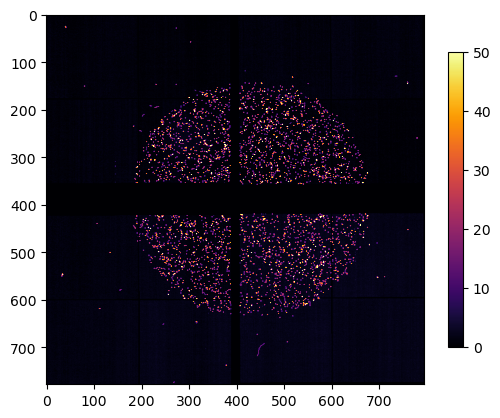

In [34]:
img_sgl = img_raw_evts_select[1] # Check one image
plt.imshow(np.transpose(img_sgl),cmap = 'inferno', vmin=0,vmax=50);plt.colorbar(shrink=0.8)

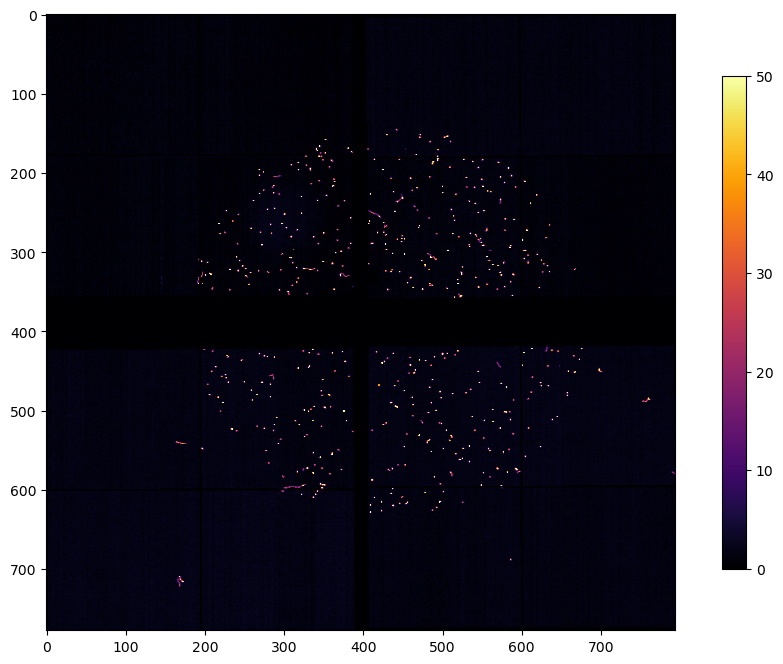

In [39]:
plt.figure(figsize=(12,8))
img_sgl = img_raw_evts_select[-1] # Check one image
plt.imshow(np.transpose(img_sgl),cmap = 'inferno', vmin=0,vmax=50);plt.colorbar(shrink=0.8)

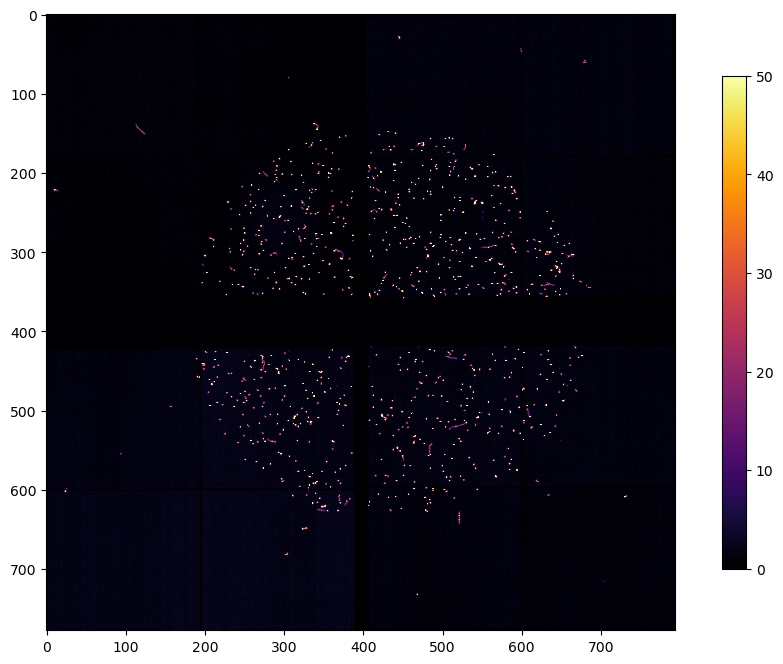

In [47]:
plt.figure(figsize=(12,8))
img_sgl = img_raw_evts_select[-1080-1000] # Check one image
plt.imshow(np.transpose(img_sgl),cmap = 'inferno', vmin=0,vmax=50);plt.colorbar(shrink=0.8)

In [37]:
# Define some trial peak finding parameters
max_electrons = 1000 # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal
# delete the dataSource to obtain the new DataSource
try:
    ds  # Try to access the variable
    print("ds exists!")
    print("ds deleted!")
    del ds
except NameError:
    print("ds does not exist.")

ds exists!
ds deleted!


In [ ]:
# Running the peak finding 
beamCenter = np.array([397,309]) # set the center manually if needed
calib_evts     = [] # Modules of each evt
img_raw_evts   = [] # Raw images
x_evts         = [] # Peak X coordinates
y_evts         = [] # Peak Y coordinates
Intensity_evts = [] # Peak intenisties
Size_evts      = [] # Peak pixel size
n_peaks_evts   = [] # 
step_evts      = [] # Delay stage position
max_events     = 450 # Load a few frames
# Load the data from xtc files

evt_count = 0 # Counter of the event
for evt in myrun.events():# sometimes dectecor doesn't have 'epixquad' resulting in badness
    # try:
    #     epix = myrun.Detector('epixquad1kfps')
    # except AttributeError:
    #     continue
    calib = epix.raw.calib(evt)
    if calib is None: # this can return none, skip if it does
        continue
    evt_count = evt_count + 1;
    if evt_count%100 == 0:
        print('Looking at evt # '+str(evt_count))
    
    # read step value
    # step_value = step_v(evt)

    # define output arrays for peaks then populate them
    n_peaks = np.zeros(calib.shape[0])
    x = np.zeros((calib.shape[0], max_electrons))
    y = np.zeros((calib.shape[0], max_electrons))
    intensities = np.zeros((calib.shape[0], max_electrons))
    sizes = np.zeros((calib.shape[0], max_electrons))
    
    # The the peakFinding algrithem
    for i,module in enumerate(calib): # loop the number of quadrants
        n, _x, _y, _ints, _sizes = blobCounter(module, threshold, min_signal)
        n_peaks[i] = n
        # either fill in first max_electrons if n>max_electrons, or fill in first n
        if n > max_electrons:
            x[i] = _x[:max_electrons]
            y[i] = _y[:max_electrons]
            intensities[i] = _ints[:max_electrons]
            sizes[i] = _sizes[:max_electrons]
        else:
            x[i][:n] = _x
            y[i][:n] = _y
            intensities[i][:n] = _ints
            sizes[i][:n] = _sizes
    calib_evts.append(calib)
    x_evts.append(x);
    y_evts.append(y);
    Intensity_evts.append(intensities);
    Size_evts.append(sizes);
    step_evts.append(0); # if not existed
    # step_evts.append(step_value);
    n_peaks_evts.append(n_peaks)
x_evts = np.array(x_evts)
y_evts = np.array(y_evts)
Intensity_evts = np.array(Intensity_evts)
Size_evts = np.array(Size_evts)
n_peaks_evts = np.array(n_peaks_evts)
step_evts = np.array(step_evts)
print(str(evt_count)+' evts are loaded')
print('Finish peak finding')
print('Delays are:'+str(np.unique(step_evts)));